<a href="https://colab.research.google.com/github/2303A52397/EXPLAINABLE-AI-2397/blob/main/EAI_ASS_6_2397.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
data = pd.read_csv("/content/kidney_disease_dataset.csv")
data.head()

,Age of the patient,Blood pressure (mm/Hg),Specific gravity of urine,Albumin in urine,Sugar in urine,Red blood cells in urine,Pus cells in urine,Pus cell clumps in urine,Bacteria in urine,Random blood glucose level (mg/dl),...,Smoking status,Body Mass Index (BMI),Physical activity level,Duration of diabetes mellitus (years),Duration of hypertension (years),Cystatin C level,Urinary sediment microscopy results,C-reactive protein (CRP) level,Interleukin-6 (IL-6) level,Target
0,54,167,1.023,1,4,normal,abnormal,not present,not present,96,...,yes,25.3,low,4.0,16.0,0.67,normal,4.88,10.23,No_Disease
1,42,127,1.023,3,2,normal,normal,not present,present,73,...,no,20.6,moderate,3.0,13.0,0.55,abnormal,4.49,13.11,Low_Risk
2,38,148,1.016,0,0,abnormal,normal,not present,not present,77,...,no,38.4,high,11.0,23.0,2.37,abnormal,4.57,13.27,No_Disease
3,7,98,1.017,4,0,abnormal,normal,not present,present,225,...,no,24.7,high,24.0,3.0,2.54,abnormal,8.57,12.36,No_Disease
4,67,174,1.015,1,1,normal,abnormal,not present,not present,376,...,yes,17.6,high,22.0,24.0,1.90,normal,6.75,1.46,No_Disease


In [ ]:
data.columns

Index(['Age of the patient', 'Blood pressure (mm/Hg)',
       'Specific gravity of urine', 'Albumin in urine', 'Sugar in urine',
       'Red blood cells in urine', 'Pus cells in urine',
       'Pus cell clumps in urine', 'Bacteria in urine',
       'Random blood glucose level (mg/dl)', 'Blood urea (mg/dl)',
       'Serum creatinine (mg/dl)', 'Sodium level (mEq/L)',
       'Potassium level (mEq/L)', 'Hemoglobin level (gms)',
       'Packed cell volume (%)', 'White blood cell count (cells/cumm)',
       'Red blood cell count (millions/cumm)', 'Hypertension (yes/no)',
       'Diabetes mellitus (yes/no)', 'Coronary artery disease (yes/no)',
       'Appetite (good/poor)', 'Pedal edema (yes/no)', 'Anemia (yes/no)',
       'Estimated Glomerular Filtration Rate (eGFR)',
       'Urine protein-to-creatinine ratio', 'Urine output (ml/day)',
       'Serum albumin level', 'Cholesterol level',
       'Parathyroid hormone (PTH) level', 'Serum calcium level',
       'Serum phosphate level', 'Family hi

In [ ]:
data['Target'].unique()

In [ ]:
data[data.select_dtypes(include='object').columns] = data.select_dtypes(include='object').apply(lambda x: x.str.strip())

In [ ]:
# Inspect shape
print("Shape:", data.shape)

Shape: (15711, 43)


In [ ]:
# Inspect datatypes
print("\nData types:\n", data.dtypes)


Data types:
 Age of the patient                               int64
Blood pressure (mm/Hg)                           int64
Specific gravity of urine                      float64
Albumin in urine                                 int64
Sugar in urine                                   int64
Red blood cells in urine                        object
Pus cells in urine                              object
Pus cell clumps in urine                        object
Bacteria in urine                               object
Random blood glucose level (mg/dl)               int64
Blood urea (mg/dl)                             float64
Serum creatinine (mg/dl)                       float64
Sodium level (mEq/L)                           float64
Potassium level (mEq/L)                        float64
Hemoglobin level (gms)                         float64
Packed cell volume (%)                         float64
White blood cell count (cells/cumm)            float64
Red blood cell count (millions/cumm)           floa

In [ ]:
# Check missing values
print("\nMissing values:\n", data.isnull().sum())


Missing values:
 Age of the patient                             0
Blood pressure (mm/Hg)                         0
Specific gravity of urine                      0
Albumin in urine                               0
Sugar in urine                                 0
Red blood cells in urine                       0
Pus cells in urine                             0
Pus cell clumps in urine                       0
Bacteria in urine                              0
Random blood glucose level (mg/dl)             0
Blood urea (mg/dl)                             0
Serum creatinine (mg/dl)                       1
Sodium level (mEq/L)                           1
Potassium level (mEq/L)                        1
Hemoglobin level (gms)                         1
Packed cell volume (%)                         1
White blood cell count (cells/cumm)            1
Red blood cell count (millions/cumm)           1
Hypertension (yes/no)                          1
Diabetes mellitus (yes/no)                     1
Co

In [ ]:
from sklearn.impute import SimpleImputer

# Drop columns with >30% missing values
threshold = 0.3 * len(data)
data = data.drop(columns=[col for col in data.columns if data[col].isnull().sum() > threshold])

# Separate numeric and categorical columns
num_cols = data.select_dtypes(include=['float64', 'int64']).columns
cat_cols = data.select_dtypes(include=['object']).columns

# Impute numeric with median, categorical with mode
num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')

data[num_cols] = num_imputer.fit_transform(data[num_cols])
data[cat_cols] = cat_imputer.fit_transform(data[cat_cols])

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
# 1. Summary statistics
print(data.describe(include='all'))

        Age of the patient  Blood pressure (mm/Hg)  Specific gravity of urine  \
count         15711.000000            15711.000000               15711.000000   
unique                 NaN                     NaN                        NaN   
top                    NaN                     NaN                        NaN   
freq                   NaN                     NaN                        NaN   
mean             47.414805              130.314493                   1.015098   
std              24.937441               29.046810                   0.005768   
min               5.000000               80.000000                   1.005000   
25%              26.000000              105.000000                   1.010000   
50%              47.000000              131.000000                   1.015000   
75%              69.000000              155.500000                   1.020000   
max              90.000000              180.000000                   1.025000   

        Albumin in urine  S

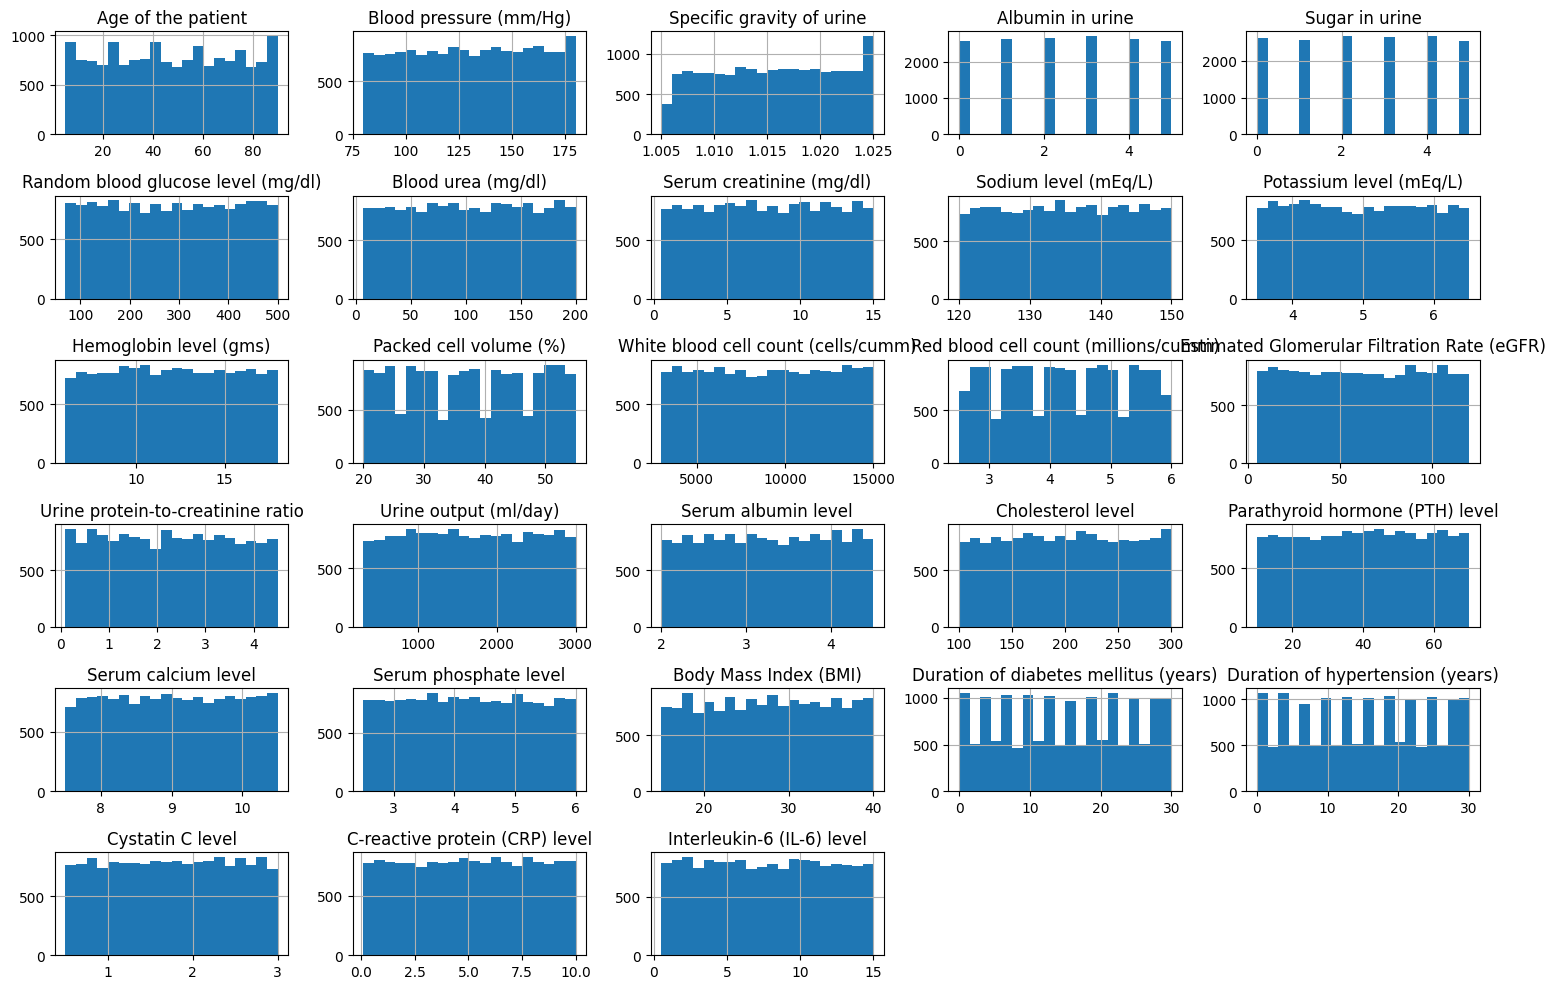

In [ ]:
# 2. Distribution plots for numeric columns
num_cols = data.select_dtypes(include=['float64', 'int64']).columns
data[num_cols].hist(figsize=(15,10), bins=20)
plt.tight_layout()
plt.show()

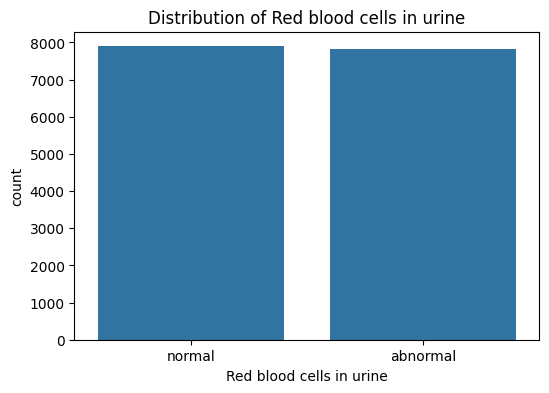

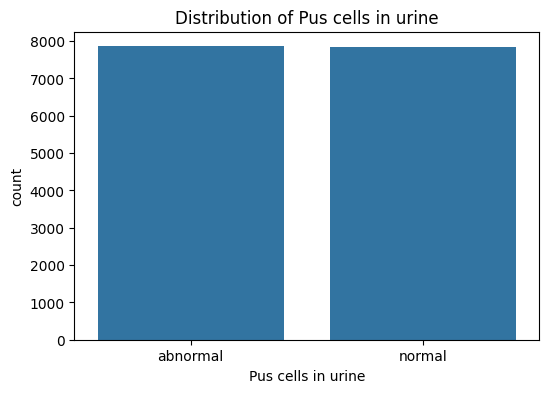

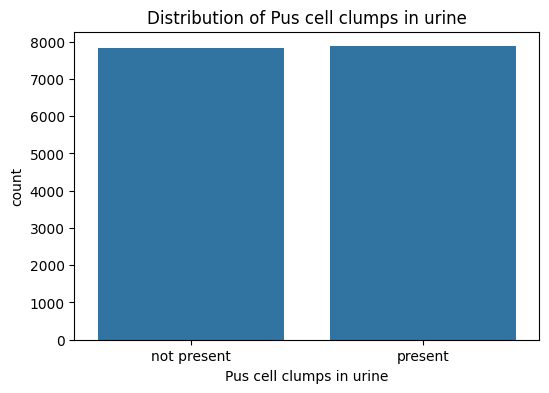

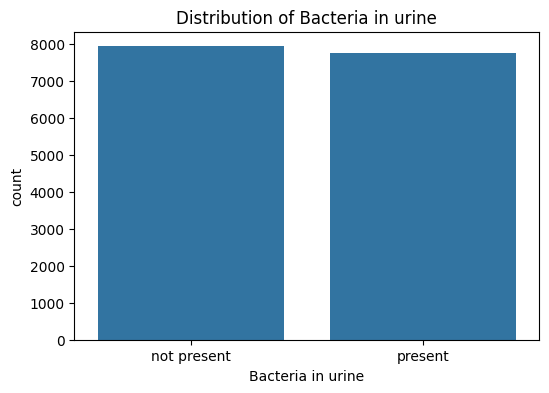

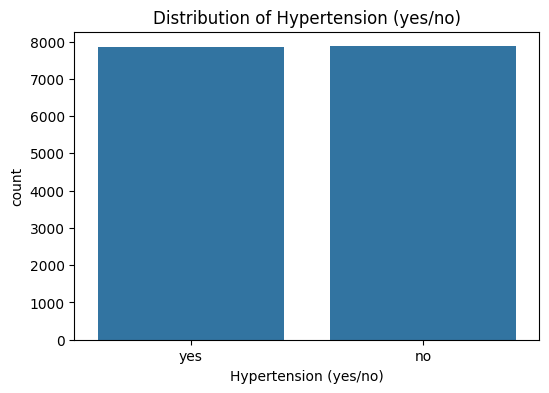

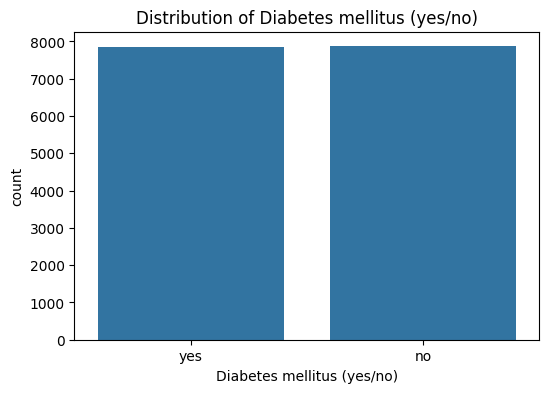

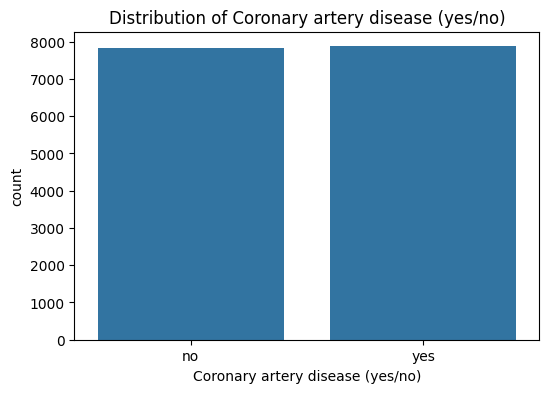

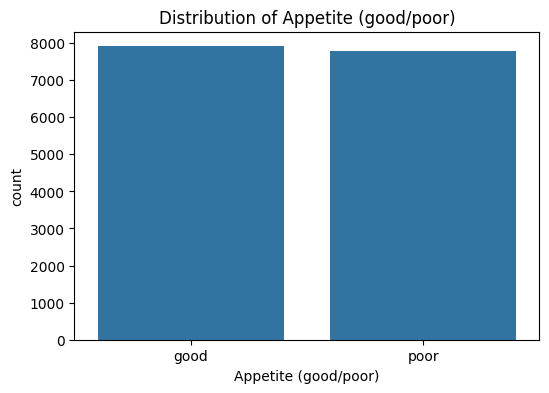

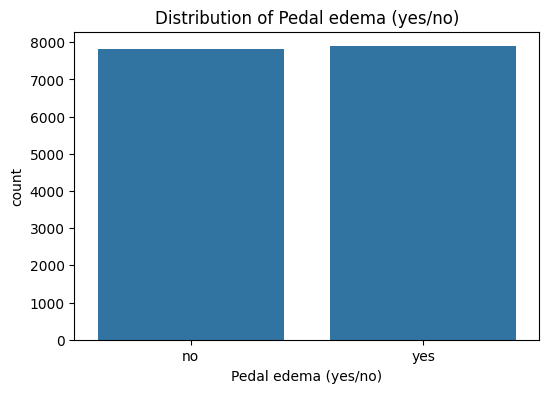

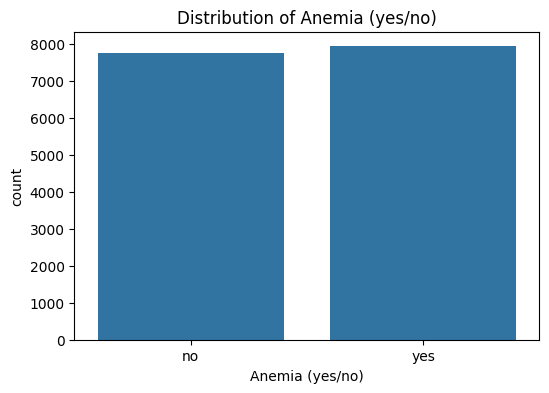

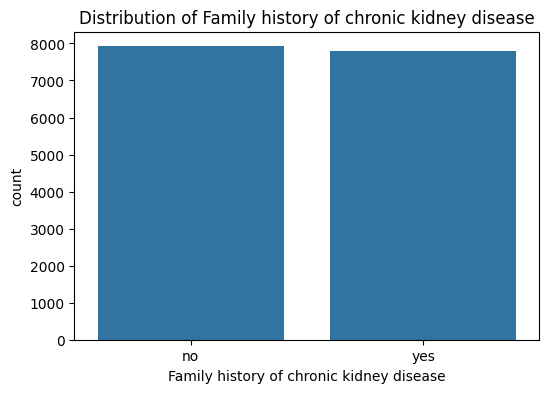

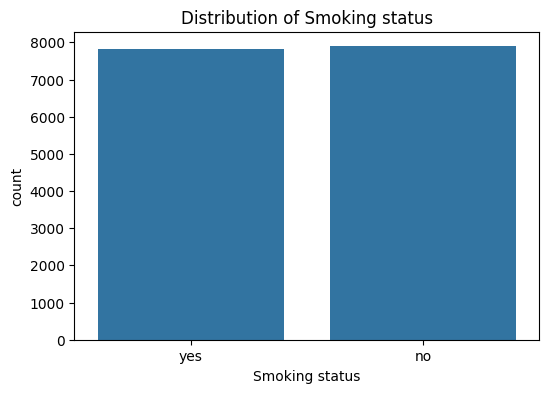

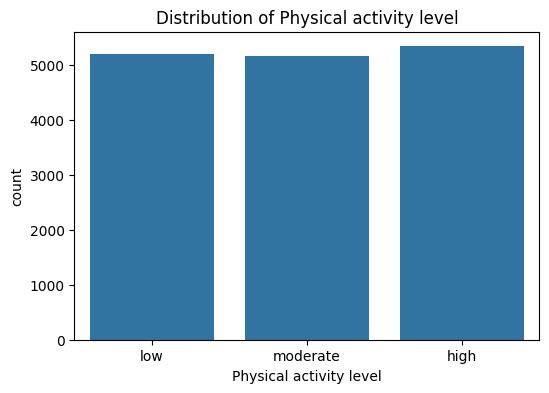

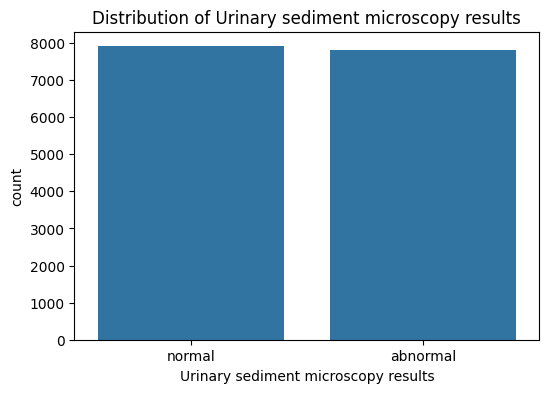

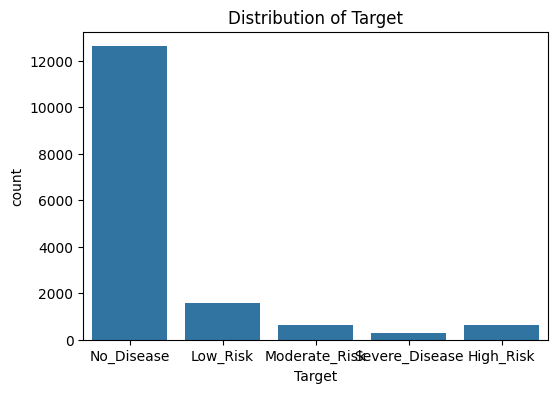

In [ ]:
# 3. Count plots for categorical columns
cat_cols = data.select_dtypes(include=['object']).columns
for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, data=data)
    plt.title(f'Distribution of {col}')
    plt.show()

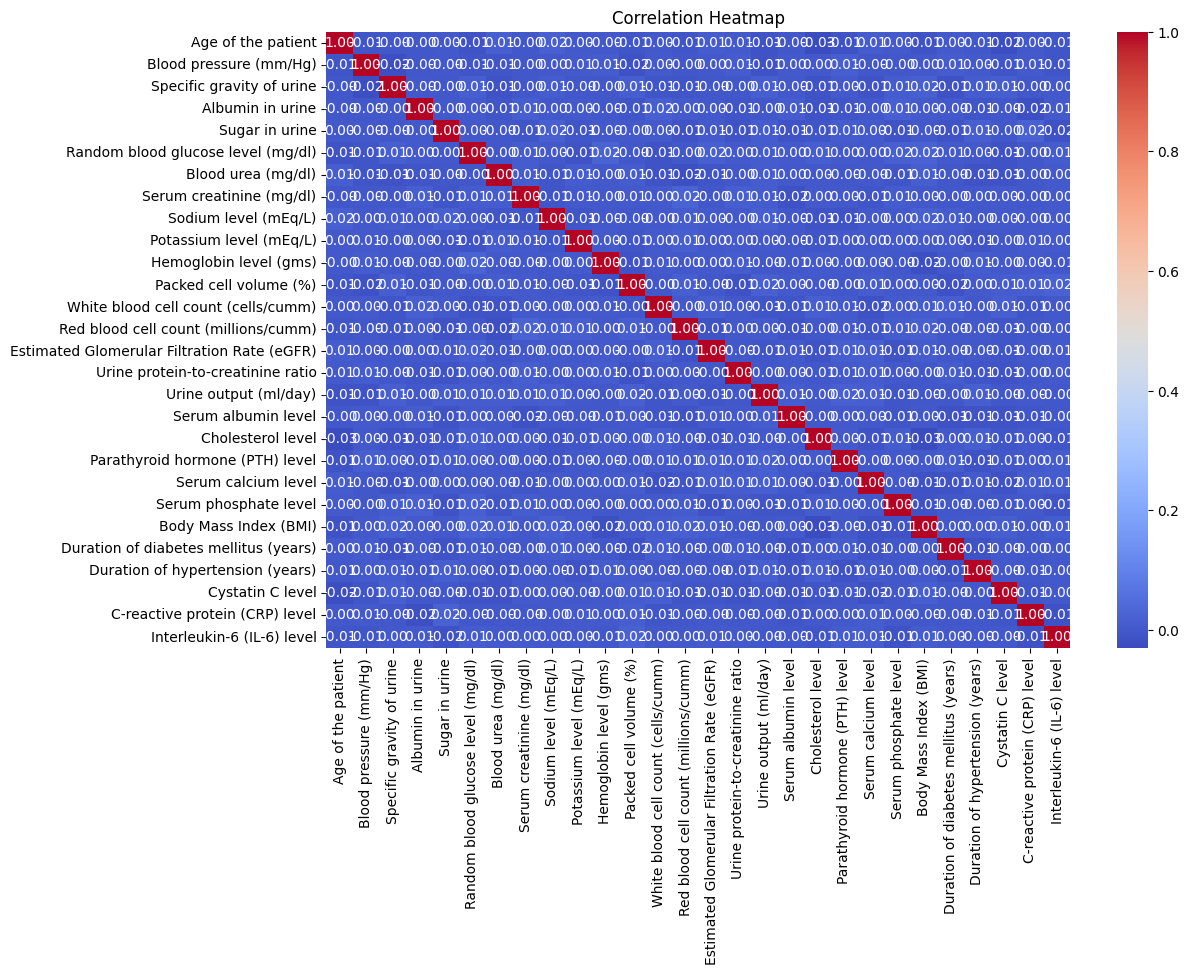

In [ ]:
# 4. Correlation heatmap for numeric columns
plt.figure(figsize=(12,8))
sns.heatmap(data[num_cols].corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

Target
No_Disease        12613
Low_Risk           1564
Moderate_Risk       625
High_Risk           609
Severe_Disease      300
Name: count, dtype: int64


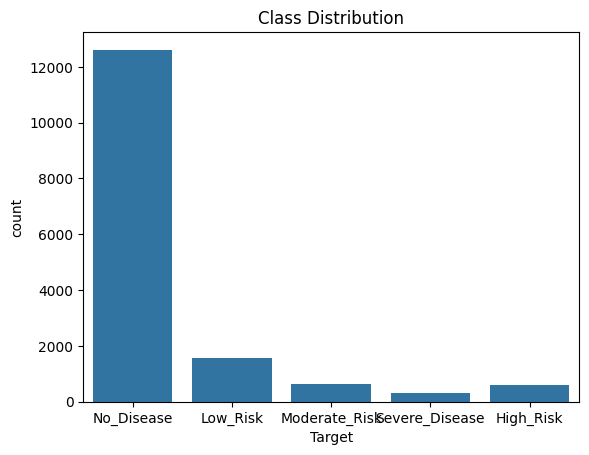

In [ ]:
# Count of each class
print(data['Target'].value_counts())

# Visualize
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Target', data=data)
plt.title("Class Distribution")
plt.show()

In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from imblearn.pipeline import Pipeline # Changed import here

X = data.drop('Target', axis=1)
y = data['Target']

# Identify categorical and numerical columns
cat_cols = X.select_dtypes(include=['object']).columns
num_cols = X.select_dtypes(include=['float64', 'int64']).columns

# Create a column transformer to apply one-hot encoding to categorical columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ])

# Create a pipeline with the preprocessor and SMOTE
pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                           ('smote', SMOTE(random_state=42))])

# Apply the pipeline to the data
X_res, y_res = pipeline.fit_resample(X, y)

# Verify new distribution
print(y_res.value_counts())

Target
No_Disease        12613
Low_Risk          12613
Moderate_Risk     12613
Severe_Disease    12613
High_Risk         12613
Name: count, dtype: int64


In [ ]:
from sklearn.preprocessing import LabelEncoder

cat_cols = data.select_dtypes(include=['object']).columns.drop('Target')
le = LabelEncoder()
for col in cat_cols:
    data[col] = le.fit_transform(data[col])

data['Target'] = data['Target'].map({'No_Disease': 0, 'Low_Risk': 1, 'Moderate_Risk': 2, 'High_Risk': 3, 'Severe_Disease': 4})
print(data.head())

   Age of the patient  Blood pressure (mm/Hg)  Specific gravity of urine  \
0                54.0                   167.0                      1.023   
1                42.0                   127.0                      1.023   
2                38.0                   148.0                      1.016   
3                 7.0                    98.0                      1.017   
4                67.0                   174.0                      1.015   

   Albumin in urine  Sugar in urine  Red blood cells in urine  \
0               1.0             4.0                         1   
1               3.0             2.0                         1   
2               0.0             0.0                         0   
3               4.0             0.0                         0   
4               1.0             1.0                         1   

   Pus cells in urine  Pus cell clumps in urine  Bacteria in urine  \
0                   0                         0                  0   
1           

In [ ]:
from sklearn.preprocessing import StandardScaler

num_cols = data.select_dtypes(include=['float64', 'int64']).columns.drop('Target')
scaler = StandardScaler()
data[num_cols] = scaler.fit_transform(data[num_cols])

print(data.head())

   Age of the patient  Blood pressure (mm/Hg)  Specific gravity of urine  \
0            0.264077                1.263019                   1.370052   
1           -0.217142               -0.114112                   1.370052   
2           -0.377549                0.608882                   0.156406   
3           -1.620699               -1.112533                   0.329784   
4            0.785398                1.504017                  -0.016973   

   Albumin in urine  Sugar in urine  Red blood cells in urine  \
0         -0.885006        0.885322                  0.994984   
1          0.294026       -0.291736                  0.994984   
2         -1.474522       -1.468794                 -1.005041   
3          0.883542       -1.468794                 -1.005041   
4         -0.885006       -0.880265                  0.994984   

   Pus cells in urine  Pus cell clumps in urine  Bacteria in urine  \
0           -0.999555                 -1.002103          -0.989426   
1           

In [ ]:
print(data.isnull().sum())

Age of the patient                             0
Blood pressure (mm/Hg)                         0
Specific gravity of urine                      0
Albumin in urine                               0
Sugar in urine                                 0
Red blood cells in urine                       0
Pus cells in urine                             0
Pus cell clumps in urine                       0
Bacteria in urine                              0
Random blood glucose level (mg/dl)             0
Blood urea (mg/dl)                             0
Serum creatinine (mg/dl)                       0
Sodium level (mEq/L)                           0
Potassium level (mEq/L)                        0
Hemoglobin level (gms)                         0
Packed cell volume (%)                         0
White blood cell count (cells/cumm)            0
Red blood cell count (millions/cumm)           0
Hypertension (yes/no)                          0
Diabetes mellitus (yes/no)                     0
Coronary artery dise

In [ ]:
from sklearn.model_selection import train_test_split

X = data.drop('Target', axis=1)
y = data['Target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Training set:", X_train.shape, y_train.shape)
print("Testing set:", X_test.shape, y_test.shape)

Training set: (12568, 42) (12568,)
Testing set: (3143, 42) (3143,)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd
import numpy as np

# Define models (reduce complexity for heavy models)
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(max_depth=10, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42),
    "SVM": SVC(probability=True, kernel='rbf', C=1, gamma='scale'),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
}

results = []

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)

    # Probabilities (for ROC-AUC)
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)
    elif hasattr(model, "decision_function"):
        # For SVM without predict_proba
        y_proba = np.exp(model.decision_function(X_test))
        y_proba = (y_proba.T / np.sum(y_proba, axis=1)).T
    else:
        y_proba = None

    # Compute metrics safely
    try:
        roc_auc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='weighted') if y_proba is not None else "N/A"
    except Exception:
        roc_auc = "N/A"

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average='weighted', zero_division=0),
        "Recall": recall_score(y_test, y_pred, average='weighted', zero_division=0),
        "F1": f1_score(y_test, y_pred, average='weighted', zero_division=0),
        "ROC-AUC": roc_auc
    })

# Display results
results_df = pd.DataFrame(results)
print("\nModel Comparison Results:")
print(results_df)

Training Logistic Regression...
Training Decision Tree...
Training Random Forest...
Training SVM...
Training KNN...
Training Gradient Boosting...

Model Comparison Results:
                 Model  Accuracy  Precision    Recall        F1   ROC-AUC
0  Logistic Regression  0.802736   0.644385  0.802736  0.714897  0.501787
1        Decision Tree  0.789691   0.666123  0.789691  0.712818  0.494960
2        Random Forest  0.802736   0.644385  0.802736  0.714897  0.508198
3                  SVM  0.802736   0.644385  0.802736  0.714897  0.471824
4                  KNN  0.793828   0.664388  0.793828  0.713604  0.510909
5    Gradient Boosting  0.798600   0.644139  0.798600  0.713101  0.507474


In [ ]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Conv1D, Flatten, LSTM, MaxPooling1D, Input

# Prepare data for CNN/RNN
X_train_dl = X_train.values.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_dl = X_test.values.reshape(X_test.shape[0], X_test.shape[1], 1)

dl_results = {}

# Number of classes
num_classes = len(data['Target'].unique())

# 1. MLP
mlp = Sequential([Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
                  Dense(32, activation='relu'),
                  Dense(num_classes, activation='softmax')])
mlp.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
mlp.fit(X_train, y_train, validation_split=0.2, epochs=50, batch_size=16, verbose=0)
y_pred = mlp.predict(X_test).argmax(axis=1)
dl_results['MLP'] = [accuracy_score(y_test, y_pred), f1_score(y_test, y_pred, average='weighted'), confusion_matrix(y_test, y_pred)]

# 2. 1D CNN
cnn = Sequential([Conv1D(32, 3, activation='relu', input_shape=(X_train.shape[1],1)),
                  Conv1D(64, 3, activation='relu'),
                  Flatten(),
                  Dense(64, activation='relu'),
                  Dense(num_classes, activation='softmax')])
cnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
cnn.fit(X_train_dl, y_train, validation_split=0.2, epochs=50, batch_size=16, verbose=0)
y_pred = cnn.predict(X_test_dl).argmax(axis=1)
dl_results['CNN'] = [accuracy_score(y_test, y_pred), f1_score(y_test, y_pred, average='weighted'), confusion_matrix(y_test, y_pred)]

# 3. LSTM
rnn = Sequential([LSTM(64, activation='tanh', input_shape=(X_train.shape[1],1)),
                  Dense(32, activation='relu'),
                  Dense(num_classes, activation='softmax')])
rnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
rnn.fit(X_train_dl, y_train, validation_split=0.2, epochs=50, batch_size=16, verbose=0)
y_pred = rnn.predict(X_test_dl).argmax(axis=1)
dl_results['LSTM'] = [accuracy_score(y_test, y_pred), f1_score(y_test, y_pred, average='weighted'), confusion_matrix(y_test, y_pred)]

# 4. Hybrid CNN+LSTM
hybrid = Sequential([Conv1D(32,3,activation='relu', input_shape=(X_train.shape[1],1)),
                     MaxPooling1D(2),
                     LSTM(64, activation='tanh'),
                     Dense(32, activation='relu'),
                     Dense(num_classes, activation='softmax')])
hybrid.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
hybrid.fit(X_train_dl, y_train, validation_split=0.2, epochs=50, batch_size=16, verbose=0)
y_pred = hybrid.predict(X_test_dl).argmax(axis=1)
dl_results['Hybrid_CNN_LSTM'] = [accuracy_score(y_test, y_pred), f1_score(y_test, y_pred, average='weighted'), confusion_matrix(y_test, y_pred)]

# 5. Autoencoder + Classifier
input_dim = X_train.shape[1]
input_layer = Input(shape=(input_dim,))
encoded = Dense(64, activation='relu')(input_layer)
encoded = Dense(32, activation='relu')(encoded)
bottleneck = Dense(16, activation='relu')(encoded)
decoded = Dense(32, activation='relu')(bottleneck)
decoded = Dense(64, activation='relu')(decoded)
output_layer = Dense(input_dim, activation='sigmoid')(decoded)
autoencoder = Model(input_layer, output_layer)
autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.fit(X_train, X_train, validation_split=0.2, epochs=50, batch_size=16, verbose=0)

encoder = Model(input_layer, bottleneck)
X_train_encoded = encoder.predict(X_train)
X_test_encoded = encoder.predict(X_test)

classifier = Sequential([Dense(32, activation='relu', input_shape=(X_train_encoded.shape[1],)),
                         Dense(num_classes, activation='softmax')])
classifier.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
classifier.fit(X_train_encoded, y_train, validation_split=0.2, epochs=50, batch_size=16, verbose=0)
y_pred = classifier.predict(X_test_encoded).argmax(axis=1)
dl_results['Autoencoder'] = [accuracy_score(y_test, y_pred), f1_score(y_test, y_pred, average='weighted'), confusion_matrix(y_test, y_pred)]

# Display results
for model, metrics in dl_results.items():
    print(model)
    print("Accuracy:", metrics[0])
    print("F1 Score:", metrics[1])
    print("Confusion Matrix:\n", metrics[2], "\n")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
393/393 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
MLP
Accuracy: 0.6913776646516068
F1 Score: 0.6710410705057116
Confusion Matrix:
 [[2147  198   83   72   23]
 [ 274   20   10    5    4]
 [ 110   12    2    1    0]
 [ 108    6    4    3    1]
 [  48    7    4    0    1]] 

CNN
Accuracy: 0.7063315303849825
F1 Score: 0.683247740908451
Confusion Matrix:
 [[2179  179   59   65   41]
 [ 267   31    4    6    5]
 [ 111    7    3    3    1]
 [ 104    9    2    5    2]
 [  53    2    2    1    2]] 

LSTM
Accuracy: 0.8027362392618518
F1 Score: 0.7148971167164321
Confusion Matrix:
 [[2523    0    0    0    0]
 [ 313    0    0    0    0]
 [ 125    0    0    0    0]
 [ 122    0    0    0    0]
 [  60    0    0    0    0]] 

Hybrid_CNN_LSTM
Accuracy: 0.7826916958320076
F1 Score: 0.7081193265466432
Confusion Matrix:
 [[2455   24   15   10   19]
 [ 307    4    1    0    1]
 [ 124    1    0    0    0]
 [ 120    1    0    1    0]
 [  60    0    0    0    0]] 

Autoencoder
Accuracy: 0.8027362392618518
F1 Score: 0.

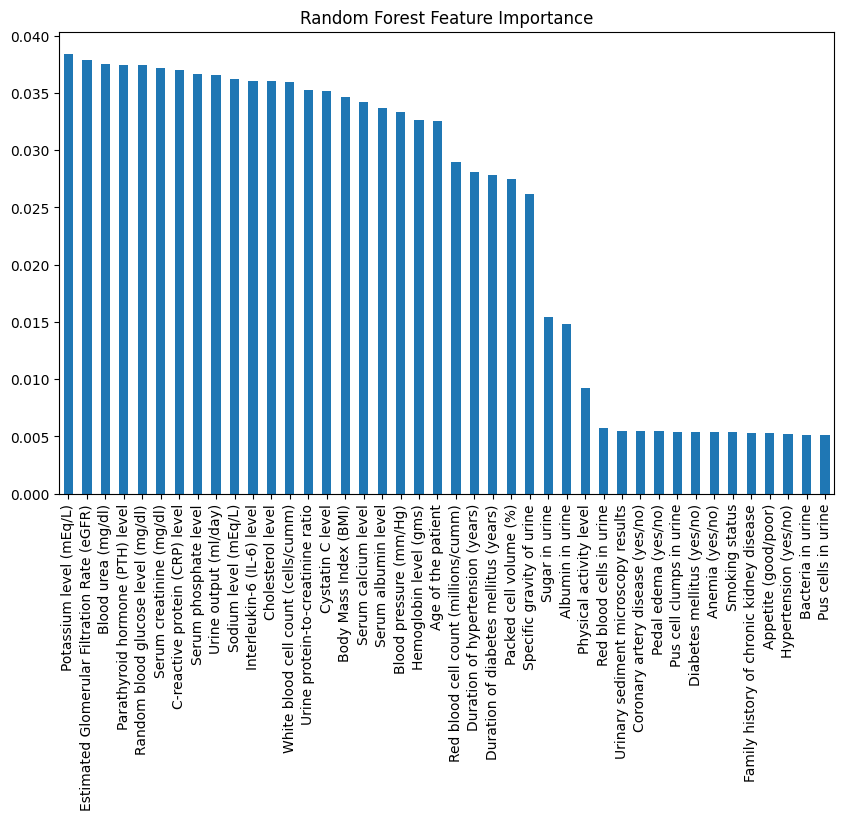

In [ ]:
# Tree-based Feature Importance
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import matplotlib.pyplot as plt

rf = RandomForestClassifier()
rf.fit(X_train, y_train)
importances = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
plt.figure(figsize=(10,6))
importances.plot(kind='bar')
plt.title("Random Forest Feature Importance")
plt.show()

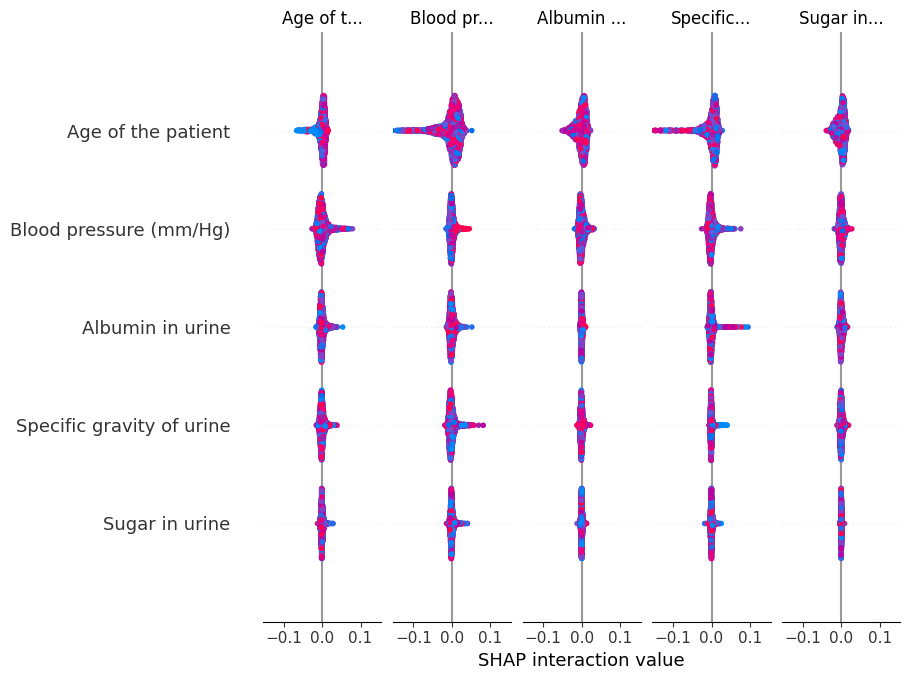

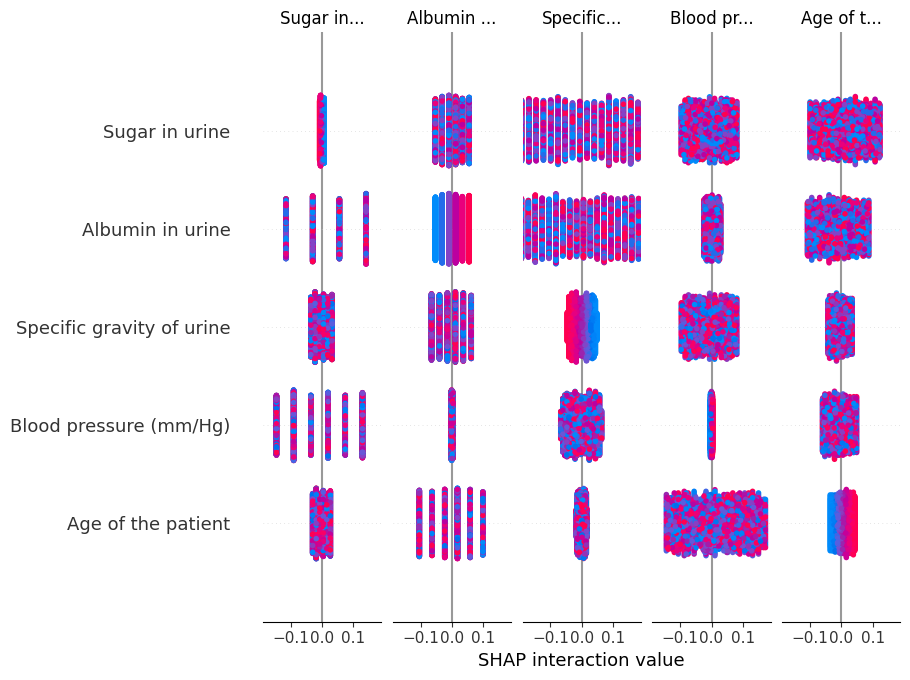

In [ ]:
# SHAP values
import shap
explainer_rf = shap.TreeExplainer(rf)
shap_values_rf = explainer_rf.shap_values(X_test)
shap.summary_plot(shap_values_rf, X_test, class_inds=1)

from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
explainer_lr = shap.LinearExplainer(lr, X_train)
shap_values_lr = explainer_lr.shap_values(X_test)
shap.summary_plot(shap_values_lr, X_test)

In [ ]:
!pip install lime


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 8.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=2e2d8605c50a20edc0db11e48315cb7bf1a991015497a4d96f58a11ec61089d9
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [ ]:
# LIME
from lime.lime_tabular import LimeTabularExplainer
import numpy as np

def mlp_predict_proba(X):
    probs_positive = mlp.predict(X)
    probs_negative = 1 - probs_positive
    return np.hstack((probs_negative, probs_positive))

explainer_lime = LimeTabularExplainer(X_train.values, feature_names=X_train.columns, class_names=['notckd','ckd'], discretize_continuous=True)
i = 0
exp = explainer_lime.explain_instance(X_test.values[i], mlp_predict_proba, num_features=10)
exp.show_in_notebook(show_table=True)


157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


/usr/local/lib/python3.12/dist-packages/lime/lime_tabular.py:372: UserWarning: 
                    Prediction probabilties do not sum to 1, and
                    thus does not constitute a probability space.
                    Check that you classifier outputs probabilities
                    (Not log probabilities, or actual class predictions).
                    
  warnings.warn("""


In [ ]:
!pip install lime --quiet

In [ ]:
from pdpbox import pdp, info_plots
import matplotlib.pyplot as plt

In [34]:
!pip install pdpbox --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.8/35.8 MB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.7/7.7 MB 37.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.1/121.1 kB 3.8 MB/s eta 0:00:00


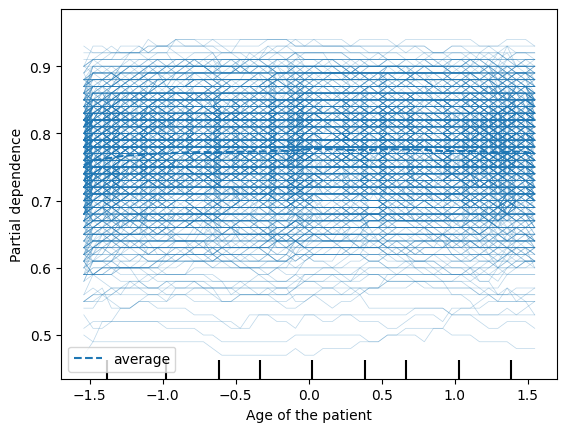

In [35]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

PartialDependenceDisplay.from_estimator(
    rf,
    X_test,
    features=['Age of the patient'], # Changed 'age' to 'Age of the patient' as per the DataFrame column name
    kind="both",
    grid_resolution=50,
    target=0 # Specify the target class (0 for 'No_Disease')
)

plt.show()